# How we retrieve two-point statistics: Dark Emulator vs cloelib native

This notebook clarifies **how we intend to obtain observables (two-point statistics)** when using the Dark Emulator integration in cloelib.

## Two possible approaches

| Approach | Observables | Typical use in CLOE |
|----------|-------------|---------------------|
| **A. cloelib native** | Angular power spectra C_l, real-space via Limber + integration | Photometric 3x2pt (WL, GCph, GGL) from *angular* Cls; EuclidLikelihood_photo_Cls |
| **B. Dark Emulator** | **Real-space** (w_p(R), ΔΣ(R), ξ_{gg}, ξ_{gm}) **directly from the emulator** | HOD-based GC + GGL (e.g. HSC-Y3 style); no C_ell step |

## Intended usage (our choice)
- “dark_emulator” python package enables fast and accurate computations of halo clustering quantities
- When working with **real-space observables** such as **ΔΣ(R)** (GGL) and **w_p(R)** (GC), **we use the Dark Emulator** to get two-point statistics—this is the pipeline to use for fitting or predicting ΔΣ, w_p, etc. We do not use cloelib’s native angular/Limber pipeline for these.
- cloelib’s role is to:
  1. Hold cosmology (e.g. `CAMBBackground`) and convert to Dark Emulator’s parameter format.
  2. Expose the emulator as **Perturbations-like** classes (`DarkEmuHODPerturbations`, etc.) that return **real-space observables** \(w_p(R), ΔΣ(R)\).
- So: **observables = Dark Emulator output**, retrieved **through cloelib’s thin wrapper** (same Python API as other perturbations, but backend is the emulator).

Below we show the **concrete usage** for retrieving these observables.

## 1. Path and imports

In [2]:
import sys
from pathlib import Path

# Find CLOE repo root (directory that contains cloelib, cloelike, dark_emulator_public)
NOTEBOOK_DIR = Path.cwd()
CLOE_ROOT = NOTEBOOK_DIR
for _ in range(6):
    if (CLOE_ROOT / "cloelib").is_dir():
        break
    CLOE_ROOT = CLOE_ROOT.parent
else:
    raise FileNotFoundError("CLOE root not found: run the notebook from inside the CLOE repo.")

sys.path.insert(0, str(CLOE_ROOT / "cloelib"))
sys.path.insert(0, str(CLOE_ROOT / "cloelike"))
sys.path.insert(0, str(CLOE_ROOT / "dark_emulator_public"))

import numpy as np
import matplotlib.pyplot as plt

from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.darkemu_cosmology import DarkEmuHODPerturbations
from cloelib.observables.darkemu_hod import DarkEmuHODParameters

print("CLOE_ROOT:", CLOE_ROOT)
print("Imports OK.")

CLOE_ROOT: /home/ryuseikano/Euclid/CLOE
Imports OK.


## 2. Observables from Dark Emulator (via cloelib)

We use **cloelib only** for:
- cosmology object (`CAMBBackground`),
- HOD parameter container (`DarkEmuHODParameters`),
- and a **thin wrapper** that calls the Dark Emulator and returns **real-space two-point statistics**.

The **actual observable values** (w_p(R), ΔΣ(R)) come **from the Dark Emulator**, not from cloelib’s native (C_l) or Limber code.

In [3]:
# Cosmology (cloelib object, used to set the emulator cosmology)
cosmo_params = {
    "H0": 67.0,
    "Omega_cdm0": 0.27,
    "Omega_b0": 0.049,
    "Omega_k0": 0.0,
    "w0": -1.0,
    "wa": 0.0,
    "As": 2.1e-9,
    "ns": 0.96,
    "mnu": 0.06,
    "N_mnu": 1,
    "gamma_MG": 0.55,
}
background = CAMBBackground(**cosmo_params)

# HOD parameters (cloelib container)
hod_params = DarkEmuHODParameters(
    logMmin=13.0,
    sigma_sq=0.3,
    logM1=14.0,
    alpha=1.0,
    kappa=1.0,
    poff=0.0,
    Roff=0.0,
)

# Redshift and scales
z = 0.5
R_bins = np.logspace(-0.5, 1.5, 15)  # h^{-1} Mpc
pimax = 100.0  # h^{-1} Mpc, for w_p

In [4]:
# Wrapper that uses Dark Emulator under the hood
pert = DarkEmuHODPerturbations(
    background=background,
    redshifts=np.array([z]),
    hod_params=hod_params,
)

# --- Observables: retrieved FROM THE DARK EMULATOR (via cloelib API) ---

# Galaxy-galaxy lensing: DeltaSigma(R) [h M_sun / pc^2]
delta_sigma = pert.delta_sigma(R_bins, z)

# Galaxy clustering: projected correlation function w_p(R) [h^{-1} Mpc]
w_p = pert.projected_correlation(R_bins, z, pimax=pimax)

print("Two-point statistics from Dark Emulator (via cloelib):")
print("  delta_sigma(R):", delta_sigma.shape, "-> first 3:", delta_sigma[:3].round(2))
print("  w_p(R):", w_p.shape, "-> first 3:", w_p[:3].round(2))

/home/ryuseikano/Euclid/CLOE/cloelib/cloelib/cosmology/darkemu_cosmology.py:131: UserWarning: Neutrino density mismatch: input omega_nu = 0.000000, but Dark Emulator assumes fixed omega_nu = 0.00064. Dark Emulator will use its internal fixed value regardless of input.
  self.cparam = background_to_darkemu_cparam(background)


Two-point statistics from Dark Emulator (via cloelib):
  delta_sigma(R): (15,) -> first 3: [20.79 15.68 11.55]
  w_p(R): (15,) -> first 3: [328.22 229.89 157.78]


## 3. Summary: where do observables come from?

- **Observables (two-point statistics)** in this workflow: **Dark Emulator**.
- **cloelib** provides: cosmology, HOD parameter handling, and a **single entry point** (`DarkEmuHODPerturbations`) that calls the emulator and returns ΔΣ(R) and w_p(R).
- We do **not** use cloelib’s native functions to compute these observables (e.g. we do not build C_l with Limber and then transform to real space for GC/GGL here).

So: **retrieval of observables = through Dark Emulator, via cloelib’s wrapper.**

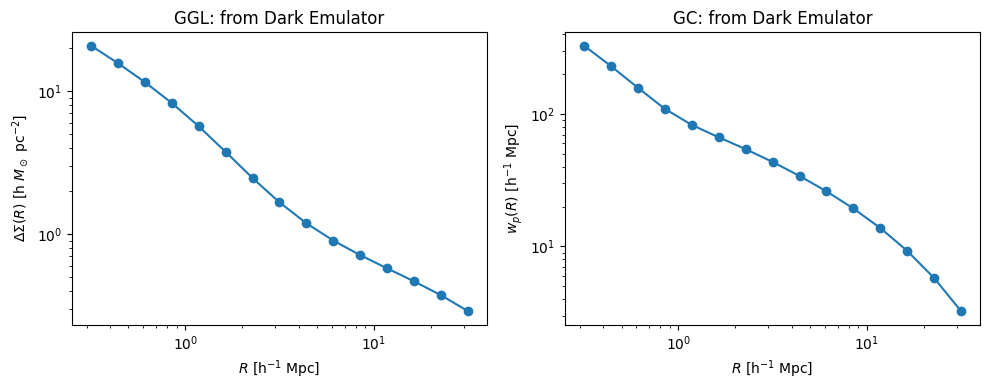

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].loglog(R_bins, delta_sigma, "o-")
axes[0].set_xlabel(r"$R$ [h$^{-1}$ Mpc]")
axes[0].set_ylabel(r"$\Delta\Sigma(R)$ [h $M_\odot$ pc$^{-2}$]")
axes[0].set_title("GGL: from Dark Emulator")

axes[1].loglog(R_bins, w_p, "o-")
axes[1].set_xlabel(r"$R$ [h$^{-1}$ Mpc]")
axes[1].set_ylabel(r"$w_p(R)$ [h$^{-1}$ Mpc]")
axes[1].set_title("GC: from Dark Emulator")

plt.tight_layout()
plt.show()